# Flood Risk Prediction — Exploratory Data Analysis
Quick look at the dataset before model training: shape, distributions, correlations, and class balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../dataset/flood_data.csv')
df.head()

,rainfall_mm,water_level_m,river_discharge_cms,temperature_c,humidity_pct,soil_moisture_pct,elevation_m,drainage_quality,historical_floods_5yr,population_density,risk_level
0,95.7,7.16,515.7,21.4,54.7,39.9,212.9,5,1,1211.0,Medium
1,59.8,6.64,10.5,25.0,60.4,32.0,79.1,1,3,654.0,High
2,55.3,8.54,468.1,27.0,60.7,49.6,229.3,4,1,4702.0,Medium
3,55.3,6.43,381.8,28.4,76.7,72.5,202.9,3,1,1954.0,Medium
4,186.0,5.16,138.8,37.2,74.9,60.3,113.8,1,0,3091.0,High


## Shape & data types

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   water_level_m          1500 non-null   float64
 2   river_discharge_cms    1500 non-null   float64
 3   temperature_c          1500 non-null   float64
 4   humidity_pct           1500 non-null   float64
 5   soil_moisture_pct      1500 non-null   float64
 6   elevation_m            1500 non-null   float64
 7   drainage_quality       1500 non-null   int64  
 8   historical_floods_5yr  1500 non-null   int64  
 9   population_density     1500 non-null   float64
 10  risk_level             1500 non-null   str    
dtypes: float64(8), int64(2), str(1)
memory usage: 129.0 KB


In [3]:
df.describe()

,rainfall_mm,water_level_m,river_discharge_cms,temperature_c,humidity_pct,soil_moisture_pct,elevation_m,drainage_quality,historical_floods_5yr,population_density
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,81.240200,4.498253,369.545333,27.032800,69.828467,44.689133,122.942067,3.114667,1.267333,1597.581333
std,55.244941,1.952404,238.006385,5.190003,14.620722,19.549377,69.689103,1.407660,1.139912,1146.196489
min,1.800000,0.200000,10.500000,10.300000,22.900000,0.000000,6.300000,1.000000,0.000000,33.000000
25%,40.000000,3.150000,199.175000,23.500000,60.000000,31.100000,71.700000,2.000000,0.000000,758.250000
50%,69.150000,4.410000,317.500000,27.000000,69.600000,44.400000,109.650000,3.000000,1.000000,1335.000000
75%,107.350000,5.852500,499.200000,30.500000,80.025000,57.500000,159.125000,4.000000,2.000000,2178.250000
max,364.400000,10.620000,1892.800000,44.000000,100.000000,100.000000,454.100000,5.000000,8.000000,10956.000000


## Class balance

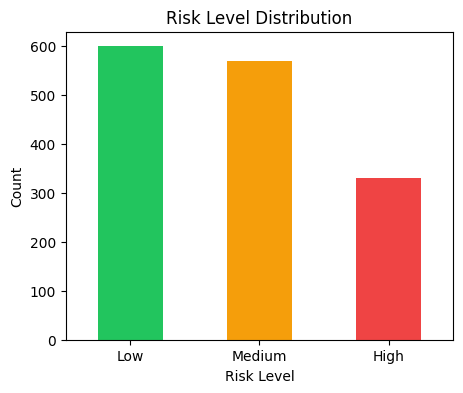

In [4]:
df['risk_level'].value_counts().reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', color=['#22c55e', '#f59e0b', '#ef4444'], figsize=(5,4), title='Risk Level Distribution'
)
plt.xlabel('Risk Level'); plt.ylabel('Count'); plt.xticks(rotation=0); plt.show()

## Feature correlation with risk

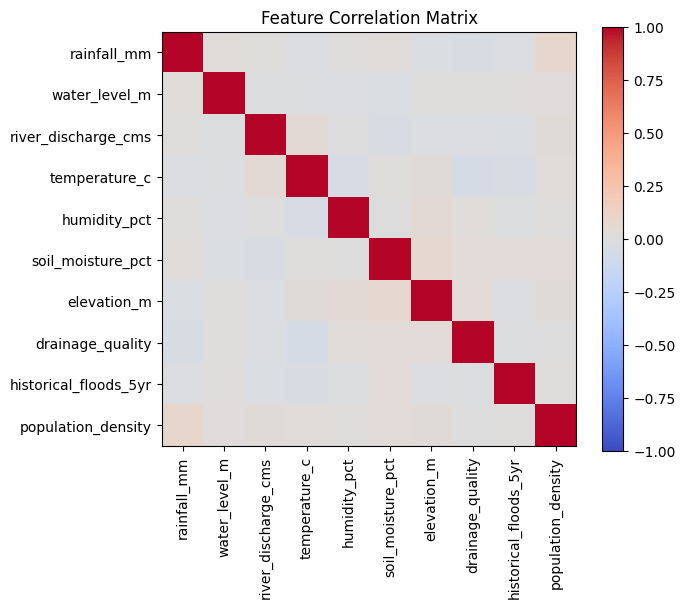

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
plt.colorbar(im); plt.title('Feature Correlation Matrix'); plt.tight_layout(); plt.show()

## Observations
- `water_level_m`, `rainfall_mm`, and `historical_floods_5yr` show the strongest positive relationship with flood risk.
- `drainage_quality` and `elevation_m` are protective — higher values push risk down.
- Classes are reasonably balanced (Low > Medium > High), so no resampling was needed before training.